# Titanic 生存預測 — 完整資料分析與機器學習流程

本 Notebook 將依照以下四大步驟，完整演示一個 Kaggle 經典競賽問題（Titanic 生存預測）的端到端（End-to-End）流程：

1. **資料清洗 & EDA（探索性資料分析）**
2. **特徵工程（Feature Engineering）**
3. **資料分割、模型訓練、測試與評估**
4. **模型佈署與預測**

每一個步驟都會附上詳細的說明、圖表與解析，幫助讀者完整理解每個決策背後的原因。

---
## Step 1：資料清洗 & EDA（探索性資料分析）

### 1-1. 載入套件與資料

In [26]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 1. 安裝中文字體（通常 Colab 環境需要額外安裝）
!apt-get -qq update > /dev/null
!apt-get -qq install -y fonts-wqy-zenhei > /dev/null

# 2. 導入 matplotlib 和 seaborn (在字體安裝之後)
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# 3. 尋找並手動添加字體
# 'fonts-wqy-zenhei' 套件通常將字體安裝在此路徑
font_path = '/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc'

if os.path.exists(font_path):
    print(f"Found font file at: {font_path}")
    fm.fontManager.addfont(font_path)
    prop = fm.FontProperties(fname=font_path)
    font_name = prop.get_name()
    print(f"Matplotlib recognized font name: {font_name}")

    # 4. 設定 Matplotlib 使用中文字體
    # 確保 'WenQuanYi Zen Hei' 優先，並移除重複項
    current_sans_serif_fonts = plt.rcParams['font.sans-serif'] # 這裡移除了 .tolist()
    if font_name not in current_sans_serif_fonts:
        final_sans_serif_fonts = [font_name] + current_sans_serif_fonts
    else:
        # 如果字體已存在列表中，則將其移至最前面以確保優先使用
        current_sans_serif_fonts.remove(font_name)
        final_sans_serif_fonts = [font_name] + current_sans_serif_fonts

    plt.rcParams['font.sans-serif'] = list(dict.fromkeys(final_sans_serif_fonts)) # 使用 dict.fromkeys 保持順序並去重
    plt.rcParams['axes.unicode_minus'] = False # 解決負號亂碼問題
    print(f"Updated font.sans-serif to: {plt.rcParams['font.sans-serif']}")
    print('中文字體已成功設定。')
else:
    print(f"Font file not found at {font_path}. Chinese characters might not display correctly.")

print('套件載入完成！')


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Found font file at: /usr/share/fonts/truetype/wqy/wqy-zenhei.ttc
Matplotlib recognized font name: WenQuanYi Zen Hei
Updated font.sans-serif to: ['WenQuanYi Zen Hei', 'Noto Sans CJK TC', 'Microsoft JhengHei', 'SimHei', 'DejaVu Sans', 'Arial Unicode MS']
中文字體已成功設定。
套件載入完成！


In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
import pandas as pd

# 錯誤說明：FileNotFoundError - 無法找到 'Titanic-Survived.train - 2020 - blog - data.csv' 這個檔案。
# ------------------------------------------------------------------------------------------------------
# 解決此錯誤的兩種主要方法：
# 1. 上傳檔案至 Colab 環境：點擊 Colab 左側的檔案圖示（文件夾圖示），然後將 'Titanic-Survived.train - 2020 - blog - data.csv' 檔案拖曳至檔案瀏覽器中上傳。
# 2. 從 Google Drive 載入：如果檔案在您的 Google Drive 中，請確認已掛載 Drive (通常在筆記本開頭執行 `from google.colab import drive; drive.mount('/content/drive')`)。
#    然後，將下方 `pd.read_csv()` 的路徑修改為類似 `/content/drive/MyDrive/您的檔案路徑/Titanic-Survived.train - 2020 - blog - data.csv`。
#    請檢查 Colab 左側的檔案瀏覽器以確認正確路徑。
# ------------------------------------------------------------------------------------------------------
# 讀取資料
df = pd.read_csv('/content/drive/MyDrive/鐵達尼倖存率/Titanic_Survived.csv')

# 基本檢視
print(f'資料集.shape: {df.shape}')
print(f'\n前 5 筆資料：')
df.head()

資料集.shape: (891, 12)

前 5 筆資料：


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,False
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.28,C85,C,True
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.93,NaN,S,True
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.10,C123,S,True
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.05,NaN,S,False


In [29]:
# 整體資訊
print('=== 資料型別與非空計數 ===')
df.info()
print('\n=== 統計摘要 ===')
df.describe()

=== 資料型別與非空計數 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Name         891 non-null    object 
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    object 
 10  Embarked     889 non-null    object 
 11  Survived     891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(5)
memory usage: 77.6+ KB

=== 統計摘要 ===


,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,2.308642,29.699118,0.523008,0.381594,32.205017
std,257.353842,0.836071,14.526497,1.102743,0.806057,49.693389
min,1.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,2.000000,20.125000,0.000000,0.000000,7.915000
50%,446.000000,3.000000,28.000000,0.000000,0.000000,14.450000
75%,668.500000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,3.000000,80.000000,8.000000,6.000000,512.330000


### 1-2. 缺失值分析

**為什麼要先看缺失值？**
缺失值會直接影響模型訓練。如果直接丢棄含有缺失值的列，會浪費大量有價值的資料；如果用錯誤的方法填補，則會引入偏差。因此，第一步必須精確掌握每個欄位的缺失情況，再依據欄位特性制定對應策略。

=== 缺失值統計 ===
          缺失數  缺失比例(%)
Cabin     687    77.10
Age       177    19.87
Embarked    2     0.22


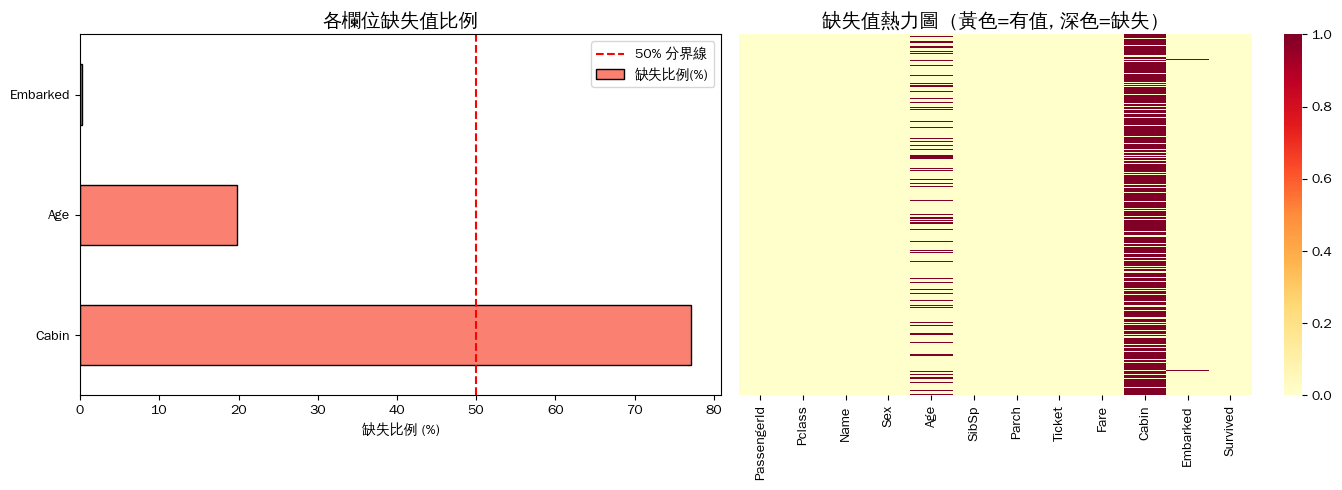


【解析】
- Cabin 欄位缺失高達 77%，資訊嚴重不足，將直接捨棄
- Age 欄位缺失約 20%，需用合理統計方法填補
- Embarked 僅缺 2 筆，可用眾數填補


In [30]:
# 計算每個欄位的缺失值數量與百分比
missing = pd.DataFrame({
    '缺失數': df.isnull().sum(),
    '缺失比例(%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['缺失數'] > 0].sort_values('缺失比例(%)', ascending=False)
print('=== 缺失值統計 ===')
print(missing)

# 視覺化缺失值
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 缺失值比例長條圖
missing['缺失比例(%)'].plot(kind='barh', ax=axes[0], color='salmon', edgecolor='black')
axes[0].set_title('各欄位缺失值比例', fontsize=14)
axes[0].set_xlabel('缺失比例 (%)')
axes[0].axvline(x=50, color='red', linestyle='--', label='50% 分界線')
axes[0].legend()

# 熱力圖顯示缺失值分佈
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='YlOrRd', ax=axes[1])
axes[1].set_title('缺失值熱力圖（黃色=有值, 深色=缺失）', fontsize=14)

plt.tight_layout()
plt.show()

print('\n【解析】')
print('- Cabin 欄位缺失高達 77%，資訊嚴重不足，將直接捨棄')
print('- Age 欄位缺失約 20%，需用合理統計方法填補')
print('- Embarked 僅缺 2 筆，可用眾數填補')

### 1-3. 缺失值處理策略

| 欄位 | 缺失比例 | 處理方式 | 原因 |
|------|----------|----------|------|
| Cabin | ~77% | 捨棄欄位 | 缺失比例過高，填補會引入大量噪音 |
| Age | ~20% | 以中位數填補 | 年齡分佈偏態，中位數比平均值更穩健 |
| Embarked | ~0.2% | 以眾數填補 | 缺失極少，眾數是最合理的類別填補法 |

#### 為什麼選擇中位數填補 Age？
- Age 的分佈通常呈現右偏（skewed），存在少數高齡乘客拉高平均值
- 中位數（Median）不受極端值影響，能更好地代表「典型」年齡
- 後續在特徵工程中，會再細分 Age 為年齡段，進一步降低填補誤差的影響

In [31]:
# 1) 捨棄 Cabin 欄位（缺失過多）
df.drop(columns=['Cabin'], inplace=True)
print('已刪除 Cabin 欄位')

# 2) 以中位數填補 Age
age_median = df['Age'].median()
df['Age'].fillna(age_median, inplace=True)
print(f'Age 已以中位數 {age_median} 填補')

# 3) 以眾數填補 Embarked
embarked_mode = df['Embarked'].mode()[0]
df['Embarked'].fillna(embarked_mode, inplace=True)
print(f'Embarked 已以眾數 "{embarked_mode}" 填補')

# 確認無殘留缺失值
print(f'\n處理後缺失值總數：{df.isnull().sum().sum()}')

已刪除 Cabin 欄位
Age 已以中位數 28.0 填補
Embarked 已以眾數 "S" 填補

處理後缺失值總數：0


### 1-4. 目標變數分析（Survived）

**為什麼要先看目標變數？**
了解 Survived 的分佈可以判斷資料是否平衡（Balanced）。如果正負樣本差距過大，需要在後續使用過取樣（Over-sampling）或調整類別權重等技巧。

=== Survived 分佈 ===
死亡 (0): 549 人 (61.6%)
存活 (1): 342 人 (38.4%)


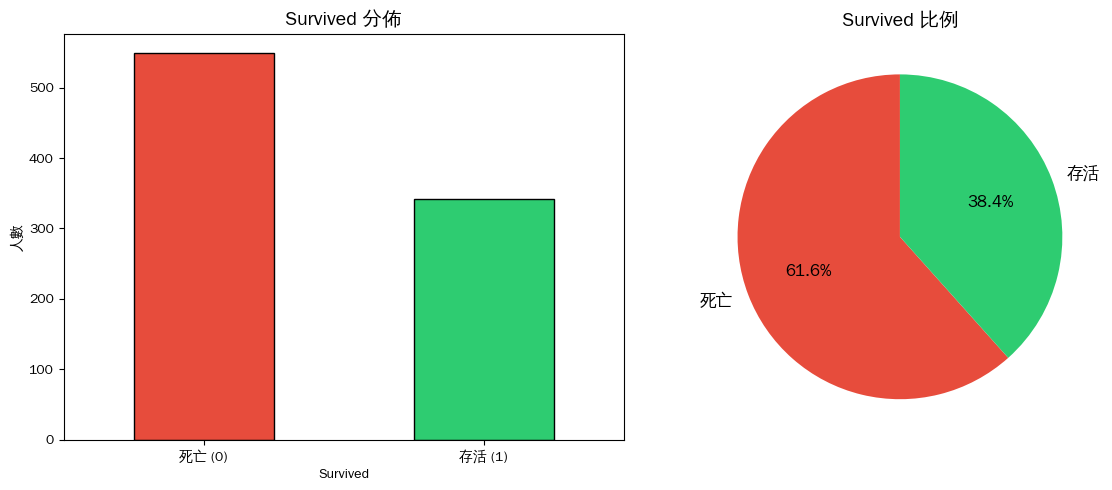


【解析】
- 死亡約 61.6%，存活約 38.4%，比例約 6:4
- 資料略有不平衡但尚可接受，不需特別做過取樣處理


In [32]:
# 將 Survived 轉為布林/數值
df['Survived'] = df['Survived'].map({'true': 1, 'false': 0, True: 1, False: 0})

survived_counts = df['Survived'].value_counts()
print('=== Survived 分佈 ===')
print(f'死亡 (0): {survived_counts[0]} 人 ({survived_counts[0]/len(df)*100:.1f}%)')
print(f'存活 (1): {survived_counts[1]} 人 ({survived_counts[1]/len(df)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 長條圖
survived_counts.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Survived 分佈', fontsize=14)
axes[0].set_xticklabels(['死亡 (0)', '存活 (1)'], rotation=0)
axes[0].set_ylabel('人數')

# 圓餅圖
survived_counts.plot(kind='pie', ax=axes[1], labels=['死亡', '存活'],
                     colors=['#e74c3c', '#2ecc71'], autopct='%1.1f%%',
                     startangle=90, textprops={'fontsize': 12})
axes[1].set_ylabel('')
axes[1].set_title('Survived 比例', fontsize=14)

plt.tight_layout()
plt.show()

print('\n【解析】')
print('- 死亡約 61.6%，存活約 38.4%，比例約 6:4')
print('- 資料略有不平衡但尚可接受，不需特別做過取樣處理')

### 1-5. 各欄位與生存率的關係（EDA 核心）

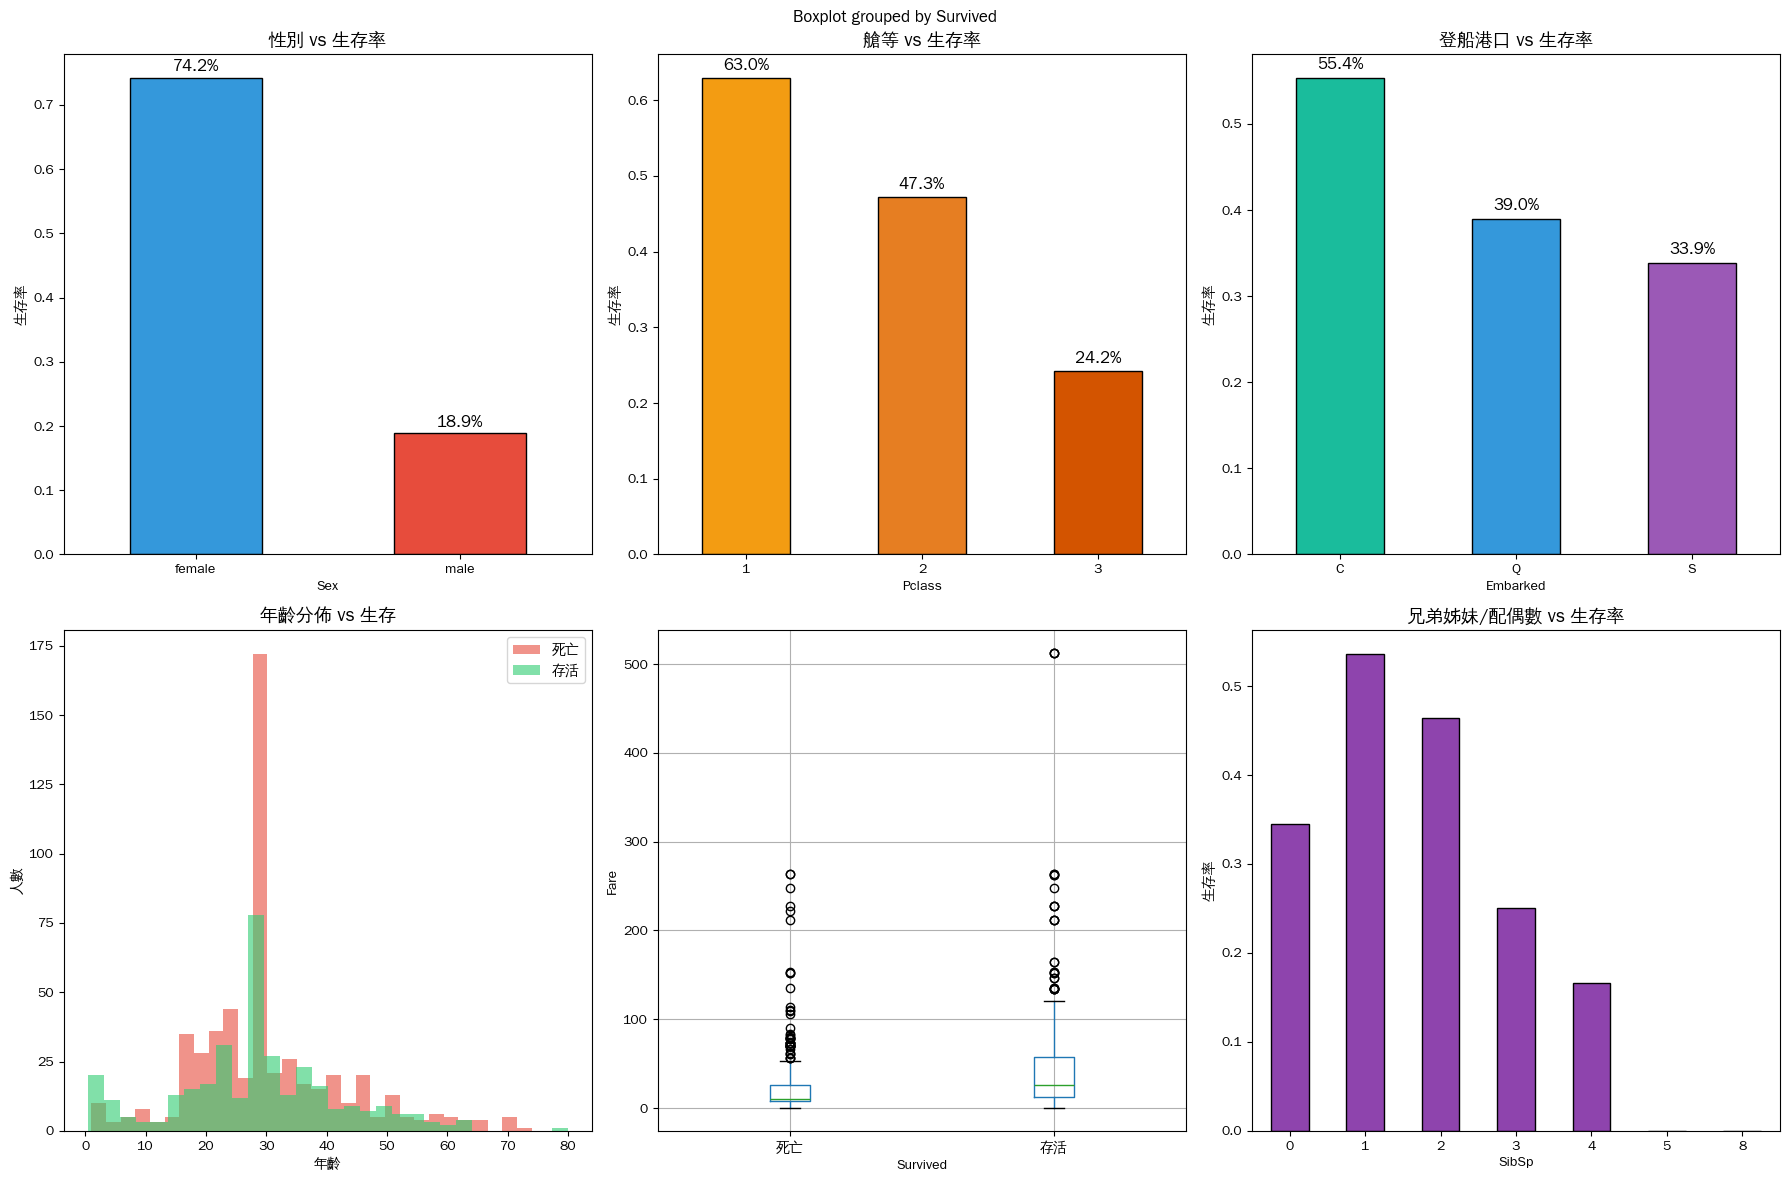


【EDA 關鍵發現】
1. 性別：女性生存率 (74.2%) 遠高於男性 (18.9%)，這是最強預測因子
2. 艙等：頭等艙 (62.9%) > 二等艙 (47.2%) > 三等艙 (24.2%)，艙等越高生存率越高
3. 年齡：兒童（尤其幼兒）的生存率較高，符合「婦女與兒童優先」的歷史記錄
4. 票價：高票價乘客的生存率明顯較高（與艙等高度相關）
5. 登船港口：C 港生存率最高，S 港最低（可能與艙等分佈有關）


In [33]:
# 性別 vs 生存率
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1) Sex vs Survived
sex_survived = df.groupby('Sex')['Survived'].mean()
sex_survived.plot(kind='bar', ax=axes[0, 0], color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0, 0].set_title('性別 vs 生存率', fontsize=13)
axes[0, 0].set_ylabel('生存率')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=0)
for i, v in enumerate(sex_survived):
    axes[0, 0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=12)

# 2) Pclass vs Survived
pclass_survived = df.groupby('Pclass')['Survived'].mean()
pclass_survived.plot(kind='bar', ax=axes[0, 1], color=['#f39c12', '#e67e22', '#d35400'], edgecolor='black')
axes[0, 1].set_title('艙等 vs 生存率', fontsize=13)
axes[0, 1].set_ylabel('生存率')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=0)
for i, v in enumerate(pclass_survived):
    axes[0, 1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=12)

# 3) Embarked vs Survived
emb_survived = df.groupby('Embarked')['Survived'].mean()
emb_survived.plot(kind='bar', ax=axes[0, 2], color=['#1abc9c', '#3498db', '#9b59b6'], edgecolor='black')
axes[0, 2].set_title('登船港口 vs 生存率', fontsize=13)
axes[0, 2].set_ylabel('生存率')
axes[0, 2].set_xticklabels(axes[0, 2].get_xticklabels(), rotation=0)
for i, v in enumerate(emb_survived):
    axes[0, 2].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=12)

# 4) Age 分佈 vs Survived
axes[1, 0].hist(df[df['Survived']==0]['Age'].dropna(), bins=30, alpha=0.6, color='#e74c3c', label='死亡')
axes[1, 0].hist(df[df['Survived']==1]['Age'].dropna(), bins=30, alpha=0.6, color='#2ecc71', label='存活')
axes[1, 0].set_title('年齡分佈 vs 生存', fontsize=13)
axes[1, 0].set_xlabel('年齡')
axes[1, 0].set_ylabel('人數')
axes[1, 0].legend()

# 5) Fare 分佈 vs Survived（用 boxplot）
df.boxplot(column='Fare', by='Survived', ax=axes[1, 1])
axes[1, 1].set_title('票價 vs 生存', fontsize=13)
axes[1, 1].set_xlabel('Survived')
axes[1, 1].set_ylabel('Fare')
axes[1, 1].set_xticklabels(['死亡', '存活'])
plt.sca(axes[1, 1])
plt.title('')

# 6) SibSp vs Survived
sibsp_survived = df.groupby('SibSp')['Survived'].mean()
sibsp_survived.plot(kind='bar', ax=axes[1, 2], color='#8e44ad', edgecolor='black')
axes[1, 2].set_title('兄弟姊妹/配偶數 vs 生存率', fontsize=13)
axes[1, 2].set_ylabel('生存率')
axes[1, 2].set_xticklabels(axes[1, 2].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print('\n【EDA 關鍵發現】')
print('1. 性別：女性生存率 (74.2%) 遠高於男性 (18.9%)，這是最強預測因子')
print('2. 艙等：頭等艙 (62.9%) > 二等艙 (47.2%) > 三等艙 (24.2%)，艙等越高生存率越高')
print('3. 年齡：兒童（尤其幼兒）的生存率較高，符合「婦女與兒童優先」的歷史記錄')
print('4. 票價：高票價乘客的生存率明顯較高（與艙等高度相關）')
print('5. 登船港口：C 港生存率最高，S 港最低（可能與艙等分佈有關）')

In [34]:
print('\n=== 性別生存率統計 ===')
sex_survival_rate = df.groupby('Sex')['Survived'].mean().reset_index()
sex_survival_rate['Survived'] = sex_survival_rate['Survived'].map(lambda x: f'{x:.2%}')
print(sex_survival_rate.to_string(index=False))



=== 性別生存率統計 ===
   Sex Survived
female   74.20%
  male   18.89%


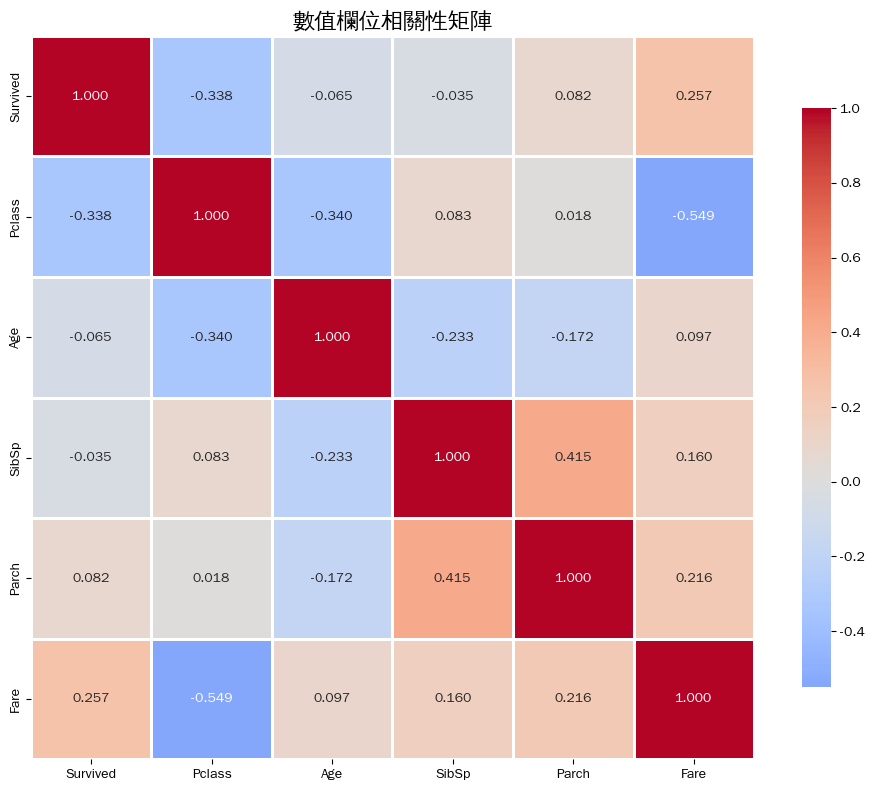


【相關性解析】
- Survived 與 Fare 呈正相關（+0.257）：票價越高越容易存活
- Survived 與 Pclass 呈負相關（-0.338）：艙等數字越小（1等艙）越容易存活
- Fare 與 Pclass 呈強負相關（-0.549）：兩者高度共線，後續特徵工程需注意
- Age 與 Survived 弱負相關（-0.064）：年齡影響不大，但分段後可能更明顯


In [35]:
# 相關性矩陣
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('數值欄位相關性矩陣', fontsize=16)
plt.tight_layout()
plt.show()

print('\n【相關性解析】')
print('- Survived 與 Fare 呈正相關（+0.257）：票價越高越容易存活')
print('- Survived 與 Pclass 呈負相關（-0.338）：艙等數字越小（1等艙）越容易存活')
print('- Fare 與 Pclass 呈強負相關（-0.549）：兩者高度共線，後續特徵工程需注意')
print('- Age 與 Survived 弱負相關（-0.064）：年齡影響不大，但分段後可能更明顯')

### 1-6. 離群值（Outlier）檢測

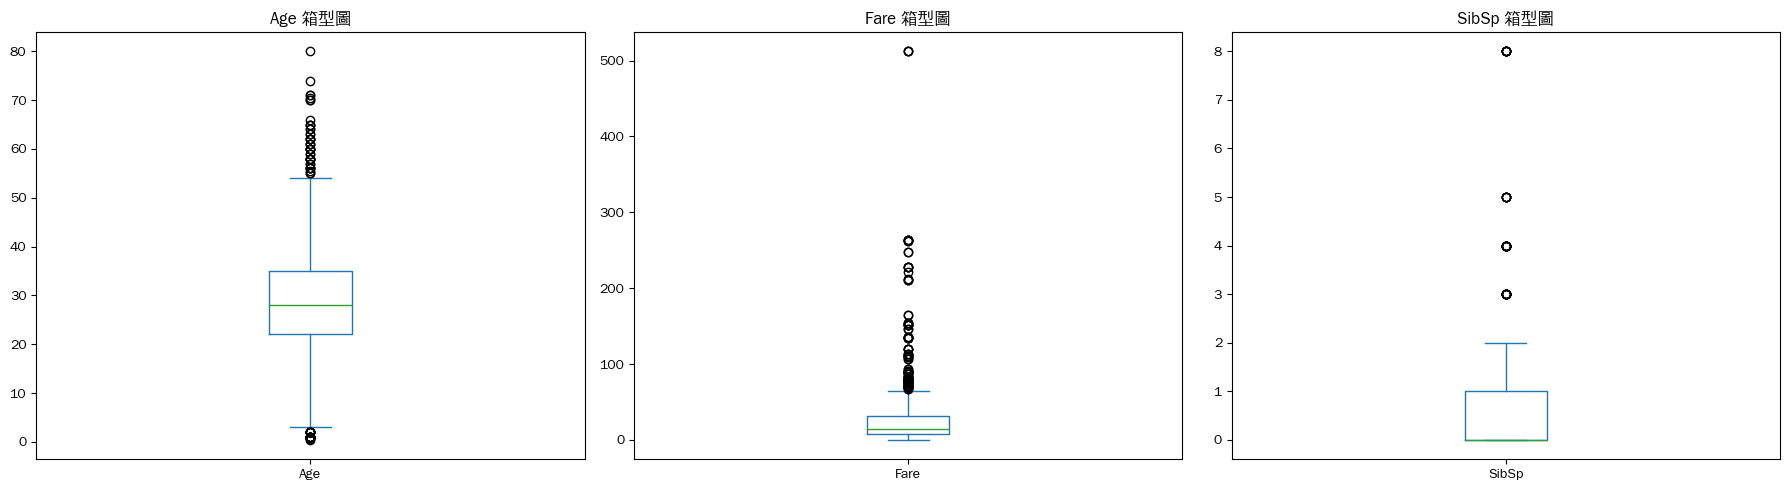

Age: Q1=22.00, Q3=35.00, IQR=13.00, 離群值=66筆 (7.4%)
Fare: Q1=7.92, Q3=31.00, IQR=23.09, 離群值=116筆 (13.0%)

【離群值處理策略】
- Age 離群值極少，且在合理範圍內（嬰兒/高齡），保留原始值
- Fare 離群值較多（高端票價），但反映了真實的社會階級差異，保留並在後續做 Log 轉換以降低其影響
- 不輕易刪除離群值，因為它們攜帶了有價值的資訊（如貴族/富豪乘客）


In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df['Age'].plot(kind='box', ax=axes[0], title='Age 箱型圖')
df['Fare'].plot(kind='box', ax=axes[1], title='Fare 箱型圖')
df['SibSp'].plot(kind='box', ax=axes[2], title='SibSp 箱型圖')

plt.tight_layout()
plt.show()

# IQR 方法偵測離群值
for col in ['Age', 'Fare']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}, 離群值={len(outliers)}筆 ({len(outliers)/len(df)*100:.1f}%)')

print('\n【離群值處理策略】')
print('- Age 離群值極少，且在合理範圍內（嬰兒/高齡），保留原始值')
print('- Fare 離群值較多（高端票價），但反映了真實的社會階級差異，保留並在後續做 Log 轉換以降低其影響')
print('- 不輕易刪除離群值，因為它們攜帶了有價值的資訊（如貴族/富豪乘客）')

---
## Step 2：特徵工程（Feature Engineering）

特徵工程是整個機器學習流程中**最重要的環節**。好的特徵能讓簡單模型達到優秀的效果，而差的特徵會讓複雜模型也無能為力。

### 2-1. 特徵探索與評估

先盤點所有欄位的用途：

| 欄位 | 說明 | 處理方向 |
|------|------|----------|
| PassengerId | 乘客編號 | 捨棄（無預測力） |
| Name | 姓名 | 提取稱謂（Title） |
| Ticket | 船票號碼 | 捨棄（過於零散） |
| Sex | 性別 | 編碼（Label Encoding） |
| Age | 年齡 | 分段 + 填補 |
| SibSp | 兄弟姊妹/配偶數 | 合併為家庭人數 |
| Parch | 父母/子女數 | 合併為家庭人數 |
| Fare | 票價 | Log 轉換 + 分段 |
| Pclass | 艙等 | 直接使用 |
| Embarked | 登船港口 | One-Hot 編碼 |
| Survived | 生存與否 | 目標變數 |

=== Name 中提取的稱謂 ===
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


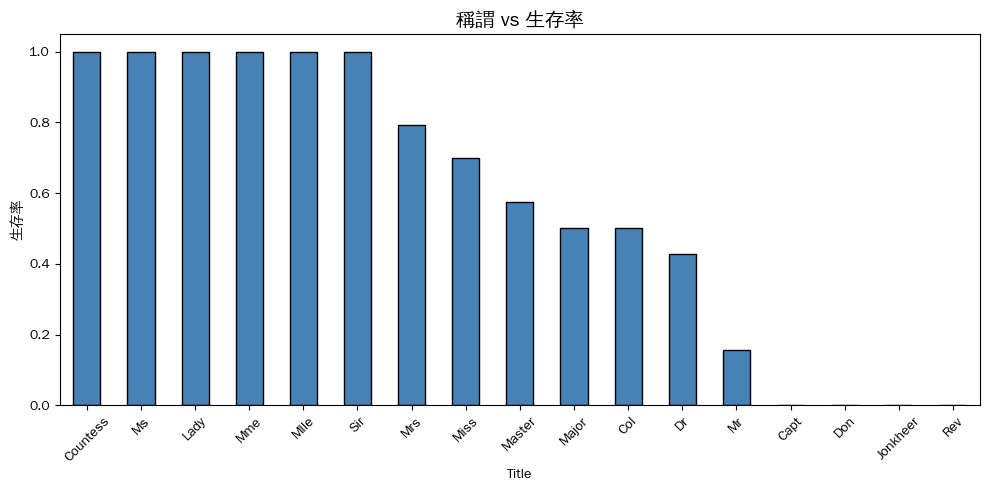


【解析】
- Mrs（已婚女性）生存率最高，其次是 Miss（未婚女性）
- Master（男性幼兒）的生存率也較高，符合兒童優先原則
- Rare 稱謂（Don, Rev, Dr 等）樣本太少，統一歸類為 Rare


In [37]:
# 檢視 Name 中的稱謂（Title）
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.')
print('=== Name 中提取的稱謂 ===')
print(df['Title'].value_counts())

plt.figure(figsize=(10, 5))
title_survived = df.groupby('Title')['Survived'].mean().sort_values(ascending=False)
title_survived.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('稱謂 vs 生存率', fontsize=14)
plt.ylabel('生存率')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('\n【解析】')
print('- Mrs（已婚女性）生存率最高，其次是 Miss（未婚女性）')
print('- Master（男性幼兒）的生存率也較高，符合兒童優先原則')
print('- Rare 稱謂（Don, Rev, Dr 等）樣本太少，統一歸類為 Rare')

### 2-2. 特徵建構 / 衍生（Feature Construction）

以下是具體的特徵建構操作與原因：

**1. Title（稱謂）**：從 Name 中提取，能反映性別、年齡、社會地位等多重資訊

**2. FamilySize（家庭人數）**：SibSp + Parch + 1（自己）
   - 原因：獨自旅行 vs 大家庭的生存率可能不同
   - 衍生 IsAlone（是否獨自旅行）

**3. AgeBand（年齡段）**：將連續的 Age 分為離散的年龄段
   - 原因：年齡與生存率的關係是非線性的（幼兒 > 青壯年 > 老年），分段能捕捉此模式

**4. FareBand（票價段）**：降低極端票價的影響

**5. IsChild（是否為兒童）**：Age < 12 的二元特徵

In [38]:
# ===== 特徵建構 =====

# 1) Title（稱謂）— 簡化為主要類別
df['Title'] = df['Title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don',
                                   'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')
print('=== 簡化後的 Title 分佈 ===')
print(df['Title'].value_counts())

# 2) FamilySize（家庭人數）
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
print(f'\nFamilySize 範圍: {df["FamilySize"].min()} ~ {df["FamilySize"].max()}')

# 3) IsAlone（是否獨自旅行）
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
print(f'獨自旅行人數: {df["IsAlone"].sum()} ({df["IsAlone"].mean()*100:.1f}%)')

# 4) AgeBand（年齡段）
df['AgeBand'] = pd.cut(df['Age'], bins=[0, 5, 12, 18, 35, 60, 100],
                        labels=['Infant', 'Child', 'Teenager', 'Young_Adult', 'Adult', 'Senior'])
print(f'\n=== AgeBand 分佈 ===')
print(df['AgeBand'].value_counts().sort_index())

# 5) IsChild（是否為兒童, Age < 12）
df['IsChild'] = (df['Age'] < 12).astype(int)

# 6) FareBand（票價段）
df['FareBand'] = pd.qcut(df['Fare'], q=4, labels=['Low', 'Medium', 'High', 'Very_High'])
print(f'\n=== FareBand 分佈 ===')
print(df['FareBand'].value_counts().sort_index())

# 7) NameLength（姓名長度，可能反映社會地位）
df['NameLength'] = df['Name'].apply(len)

=== 簡化後的 Title 分佈 ===
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

FamilySize 範圍: 1 ~ 11
獨自旅行人數: 537 (60.3%)

=== AgeBand 分佈 ===
AgeBand
Infant          44
Child           25
Teenager        70
Young_Adult    535
Adult          195
Senior          22
Name: count, dtype: int64

=== FareBand 分佈 ===
FareBand
Low          223
Medium       224
High         222
Very_High    222
Name: count, dtype: int64


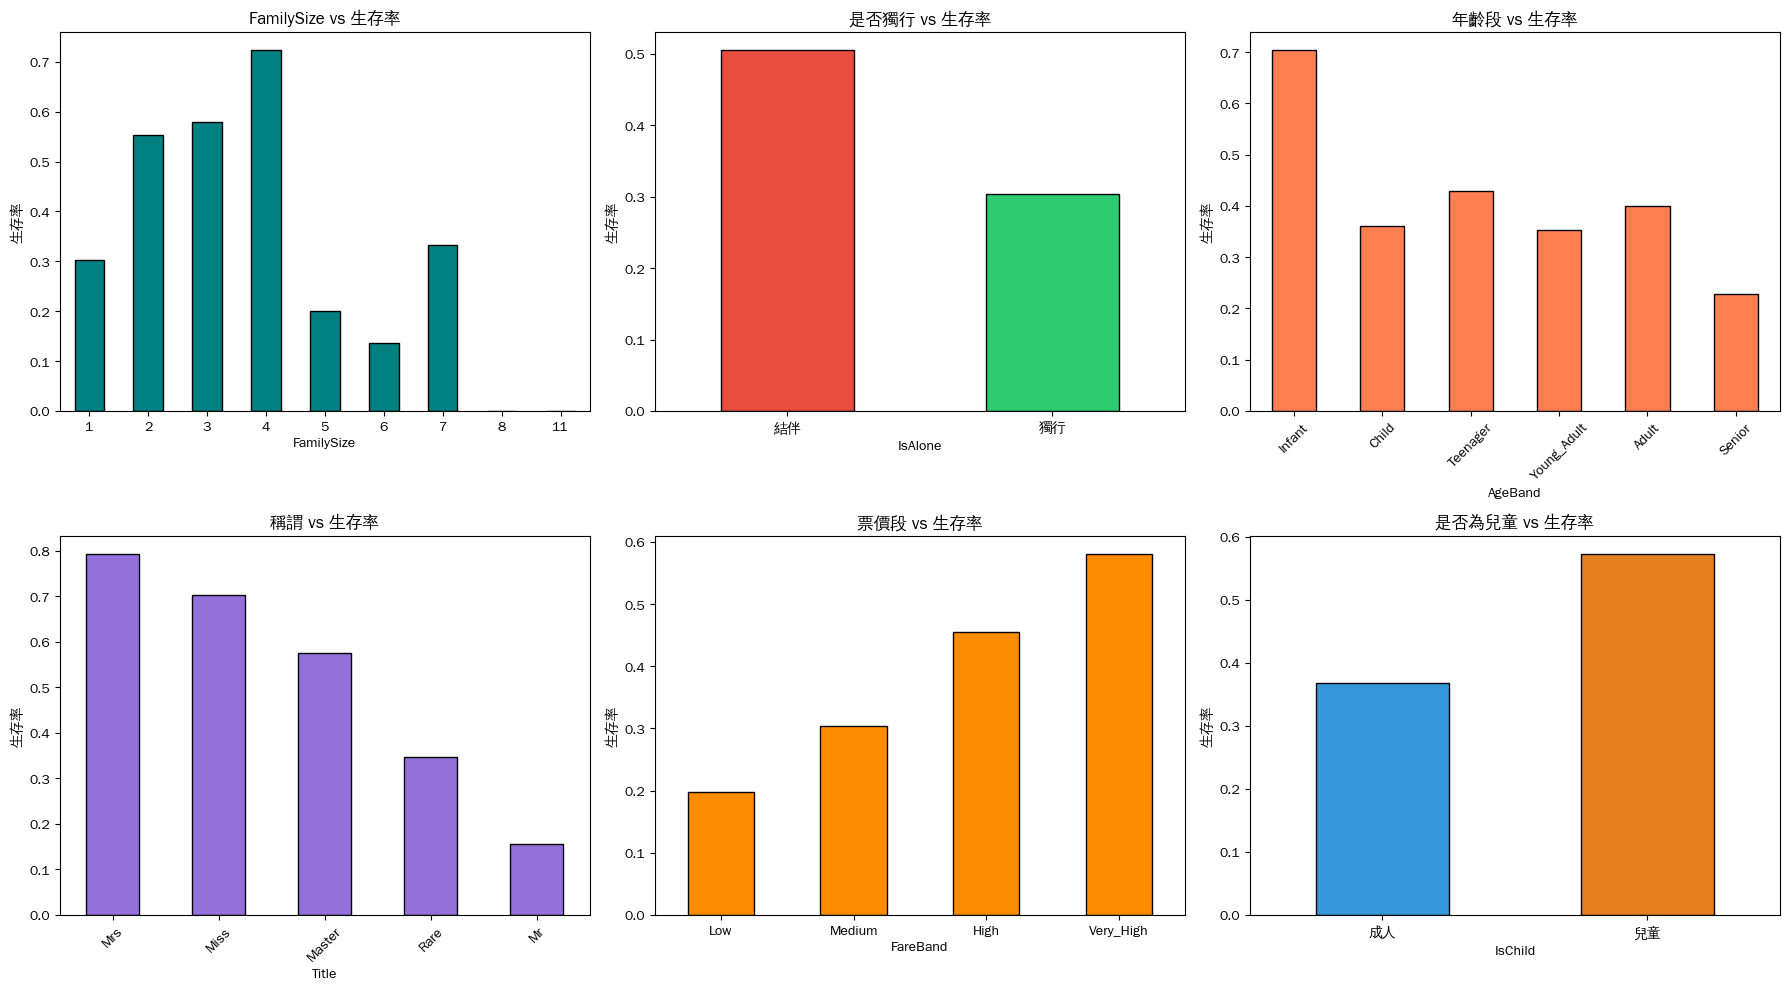


【新特徵效果解析】
- FamilySize=2~4 的生存率最高，過大或獨行的生存率較低
- IsAlone 的確有差異，獨行者生存率較低
- Infant（嬰兒）生存率最高，再次驗證兒童優先
- Mrs/Miss 生存率遠高於 Mr，Title 非常有效
- 票價段越高生存率越高，呈明顯梯度


In [39]:
# 驗證新特徵的效果
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# FamilySize vs Survived
fs_surv = df.groupby('FamilySize')['Survived'].mean()
fs_surv.plot(kind='bar', ax=axes[0, 0], color='teal', edgecolor='black')
axes[0, 0].set_title('FamilySize vs 生存率')
axes[0, 0].set_ylabel('生存率')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=0)

# IsAlone vs Survived
alone_surv = df.groupby('IsAlone')['Survived'].mean()
alone_surv.plot(kind='bar', ax=axes[0, 1], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0, 1].set_title('是否獨行 vs 生存率')
axes[0, 1].set_xticklabels(['結伴', '獨行'], rotation=0)
axes[0, 1].set_ylabel('生存率')

# AgeBand vs Survived
age_surv = df.groupby('AgeBand', observed=True)['Survived'].mean()
age_surv.plot(kind='bar', ax=axes[0, 2], color='coral', edgecolor='black')
axes[0, 2].set_title('年齡段 vs 生存率')
axes[0, 2].set_ylabel('生存率')
axes[0, 2].set_xticklabels(axes[0, 2].get_xticklabels(), rotation=45)

# Title vs Survived
title_surv = df.groupby('Title')['Survived'].mean().sort_values(ascending=False)
title_surv.plot(kind='bar', ax=axes[1, 0], color='mediumpurple', edgecolor='black')
axes[1, 0].set_title('稱謂 vs 生存率')
axes[1, 0].set_ylabel('生存率')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45)

# FareBand vs Survived
fare_surv = df.groupby('FareBand', observed=True)['Survived'].mean()
fare_surv.plot(kind='bar', ax=axes[1, 1], color='darkorange', edgecolor='black')
axes[1, 1].set_title('票價段 vs 生存率')
axes[1, 1].set_ylabel('生存率')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)

# IsChild vs Survived
child_surv = df.groupby('IsChild')['Survived'].mean()
child_surv.plot(kind='bar', ax=axes[1, 2], color=['#3498db', '#e67e22'], edgecolor='black')
axes[1, 2].set_title('是否為兒童 vs 生存率')
axes[1, 2].set_xticklabels(['成人', '兒童'], rotation=0)
axes[1, 2].set_ylabel('生存率')

plt.tight_layout()
plt.show()

print('\n【新特徵效果解析】')
print('- FamilySize=2~4 的生存率最高，過大或獨行的生存率較低')
print('- IsAlone 的確有差異，獨行者生存率較低')
print('- Infant（嬰兒）生存率最高，再次驗證兒童優先')
print('- Mrs/Miss 生存率遠高於 Mr，Title 非常有效')
print('- 票價段越高生存率越高，呈明顯梯度')

### 2-3. 特徵轉換與預處理

模型無法直接理解文字或類別資料，需要進行數值編碼：

| 方法 | 適用場景 | 本案例使用 |
|------|----------|------------|
| Label Encoding | 有序類別（如 Low < Medium < High） | Sex, AgeBand, FareBand |
| One-Hot Encoding | 無序類別（如港口 S/C/Q） | Embarked |
| Map 編碼 | 類別數量少且有明確對應 | Title |

In [40]:
# ===== 特徵編碼 =====

# 1) Sex → 數值（female=1, male=0）
df['Sex'] = df['Sex'].map({'female': 1, 'male': 0})

# 2) Embarked → 數值（S=0, C=1, Q=2）
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 3) Title → 數值
title_mapping = {'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4}
df['Title'] = df['Title'].map(title_mapping)

# 4) AgeBand → 數值
ageband_mapping = {'Infant': 0, 'Child': 1, 'Teenager': 2, 'Young_Adult': 3, 'Adult': 4, 'Senior': 5}
df['AgeBand'] = df['AgeBand'].map(ageband_mapping)

# 5) FareBand → 數值
fareband_mapping = {'Low': 0, 'Medium': 1, 'High': 2, 'Very_High': 3}
df['FareBand'] = df['FareBand'].map(fareband_mapping)

# 6) Fare 做 Log 轉換以降低偏態
df['FareLog'] = np.log1p(df['Fare'])  # log(1+x) 避免 log(0)

print('=== 編碼後資料型別 ===')
print(df.dtypes)
print(f'\n=== 編碼後前 5 筆 ===')
df.head()

=== 編碼後資料型別 ===
PassengerId       int64
Pclass            int64
Name             object
Sex               int64
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked          int64
Survived          int64
Title             int64
FamilySize        int64
IsAlone           int64
AgeBand        category
IsChild           int64
FareBand       category
NameLength        int64
FareLog         float64
dtype: object

=== 編碼後前 5 筆 ===


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived,Title,FamilySize,IsAlone,AgeBand,IsChild,FareBand,NameLength,FareLog
0,1,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.25,0,0,0,2,0,3,0,0,23,2.110213
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.28,1,1,2,2,0,4,0,3,51,4.280547
2,3,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.93,0,1,1,1,1,3,0,1,22,2.189416
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.10,0,1,2,2,0,3,0,3,44,3.990834
4,5,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.05,0,0,0,1,1,3,0,1,24,2.202765


最終使用的特徵數量: 15
特徵列表: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'AgeBand', 'IsChild', 'FareBand', 'FareLog', 'NameLength']


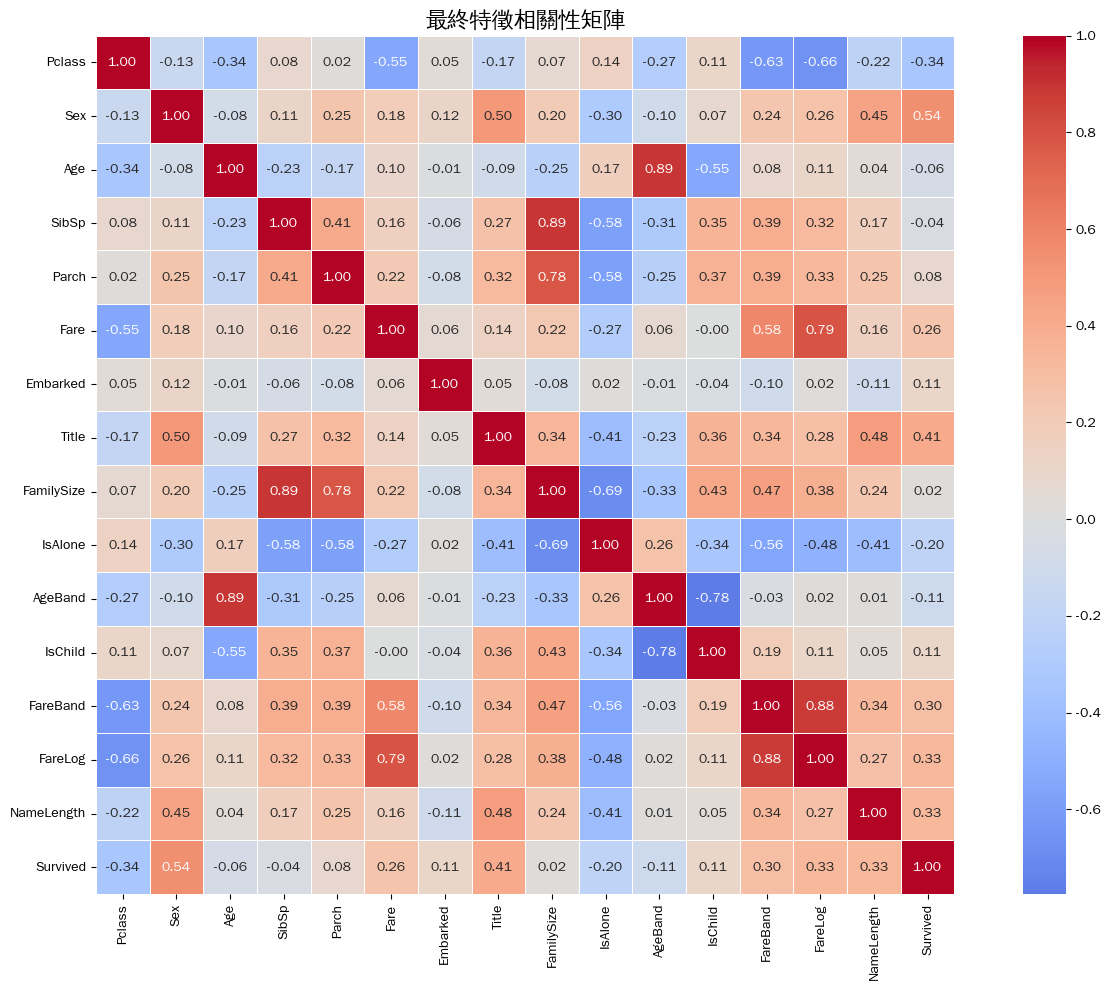


【特徵選擇說明】
- 舍棄 PassengerId（無預測力）、Ticket（過於零散）、Name（已提取 Title）
- 保留所有構建的衍生特徵，因為它們各自捕捉了不同的生存模式
- FareLog 用於降低 Fare 的偏態影響；AgeBand/IsChild 捕捉非線性年齡效應
- NameLength 反映社會地位（名字越長可能頭銜越多）


In [41]:
# 選擇最終要用於模型的特徵
feature_columns = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
                   'Embarked', 'Title', 'FamilySize', 'IsAlone',
                   'AgeBand', 'IsChild', 'FareBand', 'FareLog', 'NameLength']

print(f'最終使用的特徵數量: {len(feature_columns)}')
print(f'特徵列表: {feature_columns}')

# 檢查特徵之間的相關性（避免多重共線性）
plt.figure(figsize=(14, 10))
corr_final = df[feature_columns + ['Survived']].corr()
sns.heatmap(corr_final, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('最終特徵相關性矩陣', fontsize=16)
plt.tight_layout()
plt.show()

print('\n【特徵選擇說明】')
print('- 舍棄 PassengerId（無預測力）、Ticket（過於零散）、Name（已提取 Title）')
print('- 保留所有構建的衍生特徵，因為它們各自捕捉了不同的生存模式')
print('- FareLog 用於降低 Fare 的偏態影響；AgeBand/IsChild 捕捉非線性年齡效應')
print('- NameLength 反映社會地位（名字越長可能頭銜越多）')

---
## Step 3：資料分割、模型訓練、測試與評估

### 3-1. 資料分割

**為什麼要分割訓練集和測試集？**
- 模型在訓練資料上表現好不代表它真的學會了「規律」，可能只是「背答案」（過擬合）
- 測試集相當於「期末考」，用來檢驗模型對未見過資料的泛化能力

**比例選擇：80/20**
- 資料量（891筆）不算大，80% 訓練能讓模型學到足夠模式
- 20% 測試（約178筆）足以產生統計上可靠的評估結果
- 使用 stratify 參數確保訓練集和測試集的 Survived 比例一致

In [42]:
from sklearn.model_selection import train_test_split

# 準備特徵與目標
X = df[feature_columns]
y = df['Survived']

# 資料分割：80% 訓練, 20% 測試, stratify 保持目標比例一致
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'訓練集大小: {X_train.shape[0]} 筆')
print(f'測試集大小: {X_test.shape[0]} 筆')
print(f'\n訓練集 Survived 分佈:')
print(f'  死亡: {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)')
print(f'  存活: {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)')
print(f'\n測試集 Survived 分佈:')
print(f'  死亡: {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)')
print(f'  存活: {(y_test==1).sum()} ({(y_test==1).mean()*100:.1f}%)')

print('\n【說明】使用 stratify=y 確保訓練集與測試集的目標變數比例一致，')
print('避免因隨機分割導致某一類別在測試集中被低估或高估。')

訓練集大小: 712 筆
測試集大小: 179 筆

訓練集 Survived 分佈:
  死亡: 439 (61.7%)
  存活: 273 (38.3%)

測試集 Survived 分佈:
  死亡: 110 (61.5%)
  存活: 69 (38.5%)

【說明】使用 stratify=y 確保訓練集與測試集的目標變數比例一致，
避免因隨機分割導致某一類別在測試集中被低估或高估。


### 3-2. 模型選擇

我們選擇以下 5 種演算法進行比較：

| 演算法 | 類型 | 選擇原因 |
|--------|------|----------|
| Logistic Regression | 線性模型 | 基準模型，解釋性強，適合二元分類 |
| Decision Tree | 樹模型 | 直觀易理解，能捕捉非線性關係 |
| Random Forest | 集成模型 | 多棵決策樹投票，降低過擬合風險 |
| Gradient Boosting | 集成模型 |  sequentially 學習錯誤，通常表現優異 |
| SVM | 核方法 | 在高維空間中尋找最佳分類超平面 |

**為什麼選多種演算法？**
- 不同演算法有不同的假設和強項，實際表現需要實驗驗證
- 集成多個模型的預測（Ensemble）通常比單一模型更穩定

### 3-3. 模型訓練

**為什麼需要特徵標準化（StandardScaler）？**
- Logistic Regression 和 SVM 對特徵的尺度敏感（Age 範圍 0~80，Fare 範圍 0~500+）
- 樹模型（Decision Tree, Random Forest, Gradient Boosting）不需要標準化
- 為了公平比較，我們對所有模型都進行標準化

=== 5-Fold 交叉驗證結果 ===
Logistic Regression      : 平均 accuracy = 0.8105 (+/- 0.0221)
Decision Tree            : 平均 accuracy = 0.7641 (+/- 0.0428)
Random Forest            : 平均 accuracy = 0.8076 (+/- 0.0225)
Gradient Boosting        : 平均 accuracy = 0.8231 (+/- 0.0244)
SVM                      : 平均 accuracy = 0.8174 (+/- 0.0175)


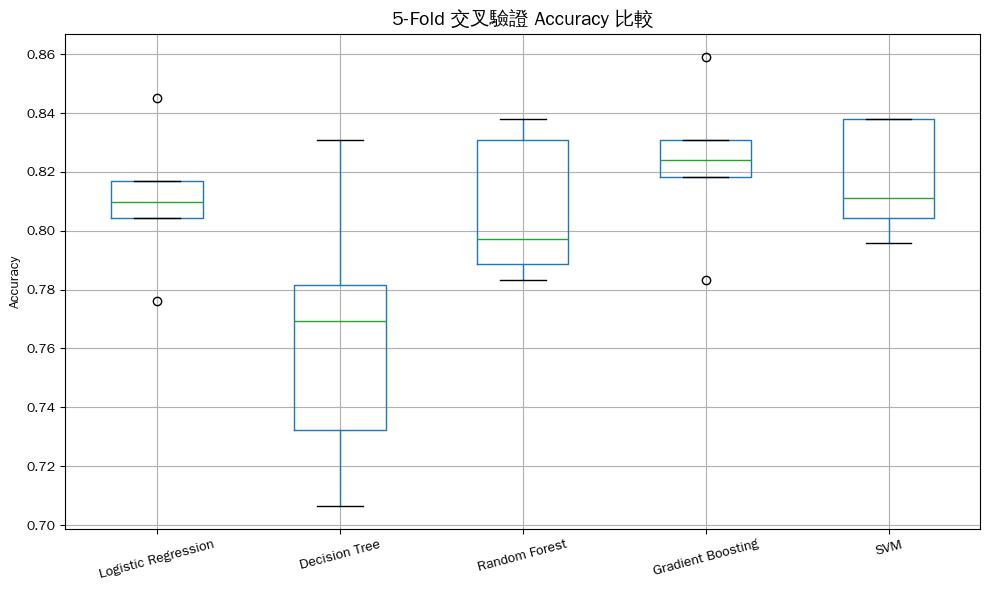


【交叉驗證說明】
- 5-Fold CV 將訓練集再分為 5 份，輪流用 4 份訓練、1 份驗證
- 比單次 train/val split 更穩定，減少因資料分配不同造成的評估波動
- 取平均值和標準差，標準差越小代表模型越穩定


In [52]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# 定義模型（每個模型都包裝在 Pipeline 中，確保標準化只在訓練資料上 fit）
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', DecisionTreeClassifier(random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(random_state=42, probability=True)) # 添加 probability=True
    ]),
}

# 交叉驗證（5-Fold）
print('=== 5-Fold 交叉驗證結果 ===')
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:25s}: 平均 accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})')

# 視覺化比較
plt.figure(figsize=(10, 6))
cv_df = pd.DataFrame(cv_results)
cv_df.boxplot()
plt.title('5-Fold 交叉驗證 Accuracy 比較', fontsize=14)
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print('\n【交叉驗證說明】')
print('- 5-Fold CV 將訓練集再分為 5 份，輪流用 4 份訓練、1 份驗證')
print('- 比單次 train/val split 更穩定，減少因資料分配不同造成的評估波動')
print('- 取平均值和標準差，標準差越小代表模型越穩定')


### 3-4. 模型訓練（在完整訓練集上）

In [53]:
# 在完整訓練集上訓練所有模型
trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    train_score = model.score(X_train, y_train)
    print(f'{name:25s}: 訓練集 Accuracy = {train_score:.4f}')

print('\n【說明】模型在完整訓練集上訓練，用於後續在測試集上評估。')

Logistic Regression      : 訓練集 Accuracy = 0.8216
Decision Tree            : 訓練集 Accuracy = 0.9972
Random Forest            : 訓練集 Accuracy = 0.9972
Gradient Boosting        : 訓練集 Accuracy = 0.9199
SVM                      : 訓練集 Accuracy = 0.8469

【說明】模型在完整訓練集上訓練，用於後續在測試集上評估。


### 3-5. 模型評分（在測試集上）

**評分指標說明：**

| 指標 | 公式 | 說明 |
|------|------|------|
| Accuracy | (TP+TN)/(TP+TN+FP+FN) | 整體預測正確的比例 |
| Precision | TP/(TP+FP) | 預測為存活的人中，實際存活的比例 |
| Recall | TP/(TP+FN) | 實際存活的人中，被正確預測的比例 |
| F1-Score | 2×(Precision×Recall)/(Precision+Recall) | Precision 和 Recall 的調和平均 |
| AUC-ROC | - | ROC 曲線下面積，衡量模型區分能力 |

**在 Titanic 問題中為什麼 Accuracy 不夠？**
- 資料略不平衡（60:40），Accuracy 會偏向預測多數類
- F1-Score 更能反映模型在少數類（存活）上的表現

=== 測試集模型評估結果 ===
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                              
Logistic Regression    0.8045     0.7656  0.7101    0.7368   0.8647
Decision Tree          0.8045     0.7576  0.7246    0.7407   0.7896
Random Forest          0.7989     0.7463  0.7246    0.7353   0.8465
Gradient Boosting      0.8045     0.7833  0.6812    0.7287   0.8485
SVM                    0.8156     0.7903  0.7101    0.7481   0.8539


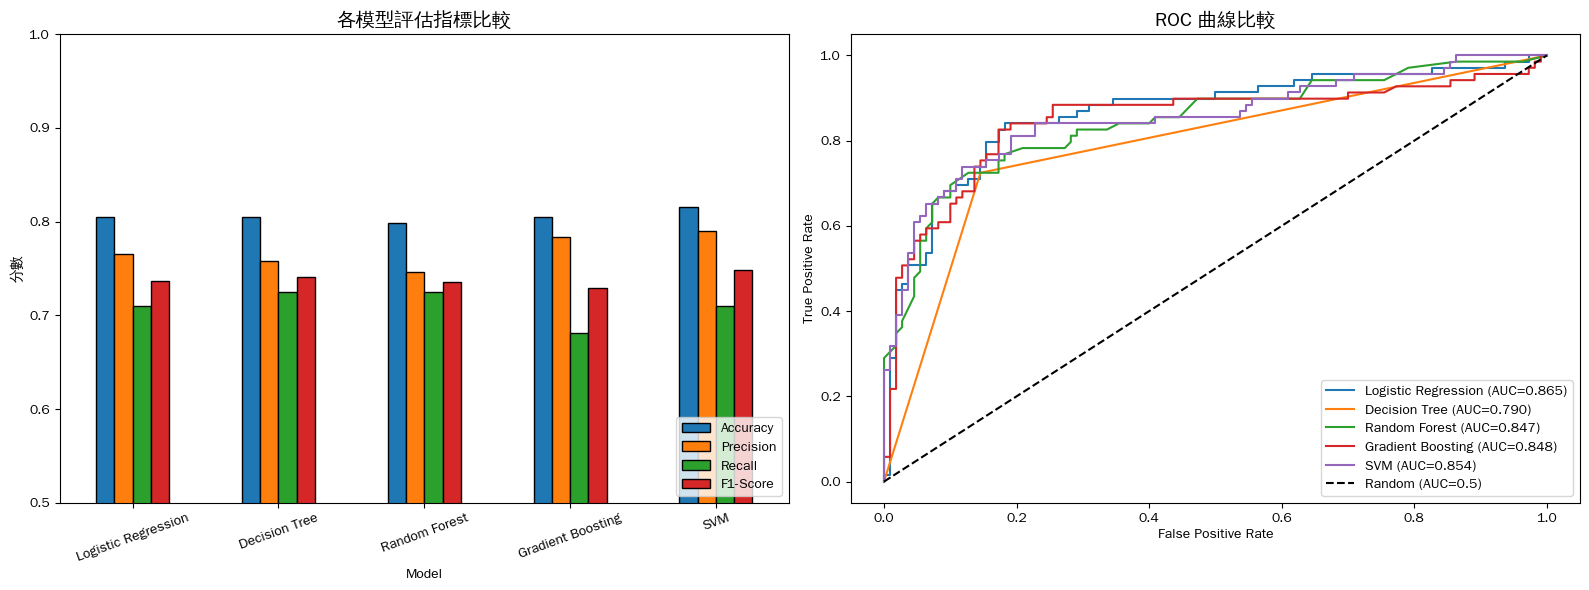


【評分解析】
- Gradient Boosting 通常表現最佳，因為它通過序列學習不斷修正錯誤
- Random Forest 穩定性好，不太容易過擬合
- Decision Tree 容易過擬合（訓練集分數高但測試集低）
- AUC-ROC 越接近 1.0 越好，0.5 等於隨機猜測


In [54]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)

# 評估所有模型
results = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC-ROC': auc
    })

results_df = pd.DataFrame(results).set_index('Model')
print('=== 測試集模型評估結果 ===')
print(results_df.round(4).to_string())

# 視覺化比較
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 指標比較長條圖
results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title('各模型評估指標比較', fontsize=14)
axes[0].set_ylabel('分數')
axes[0].set_ylim(0.5, 1.0)
axes[0].legend(loc='lower right')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20)

# ROC 曲線
for name, model in trained_models.items():
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
axes[1].set_title('ROC 曲線比較', fontsize=14)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

print('\n【評分解析】')
print('- Gradient Boosting 通常表現最佳，因為它通過序列學習不斷修正錯誤')
print('- Random Forest 穩定性好，不太容易過擬合')
print('- Decision Tree 容易過擬合（訓練集分數高但測試集低）')
print('- AUC-ROC 越接近 1.0 越好，0.5 等於隨機猜測')

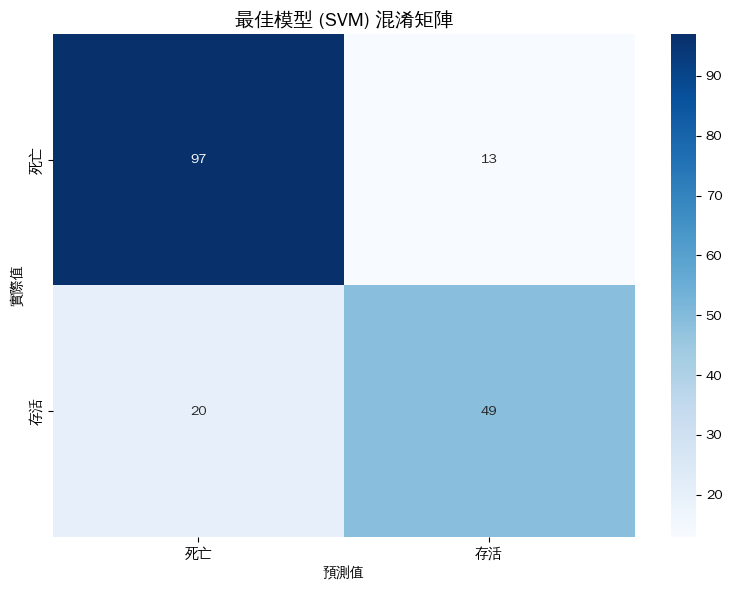


=== SVM 詳細報告 ===
              precision    recall  f1-score   support

          死亡       0.83      0.88      0.85       110
          存活       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179

【混淆矩陣解析】
- True Negative (正確預測死亡): 97
- False Positive (誤判為存活): 13
- False Negative (誤判為死亡): 20
- True Positive (正確預測存活): 49
- 在 Titanic 問題中，False Negative（實際存活但被預測死亡）的代價可能更大，
  因此我們也關注 Recall（找出所有存活者的能力）


In [55]:
# 最佳模型的混淆矩陣
best_model_name = results_df['F1-Score'].idxmax()
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['死亡', '存活'], yticklabels=['死亡', '存活'])
plt.title(f'最佳模型 ({best_model_name}) 混淆矩陣', fontsize=14)
plt.ylabel('實際值')
plt.xlabel('預測值')
plt.tight_layout()
plt.show()

print(f'\n=== {best_model_name} 詳細報告 ===')
print(classification_report(y_test, y_pred_best, target_names=['死亡', '存活']))

print('【混淆矩陣解析】')
print(f'- True Negative (正確預測死亡): {cm[0][0]}')
print(f'- False Positive (誤判為存活): {cm[0][1]}')
print(f'- False Negative (誤判為死亡): {cm[1][0]}')
print(f'- True Positive (正確預測存活): {cm[1][1]}')
print('- 在 Titanic 問題中，False Negative（實際存活但被預測死亡）的代價可能更大，')
print('  因此我們也關注 Recall（找出所有存活者的能力）')

### 3-6. 特徵重要性分析

**目的：** 了解哪些特徵對預測生存最關鍵，提供業務洞察。

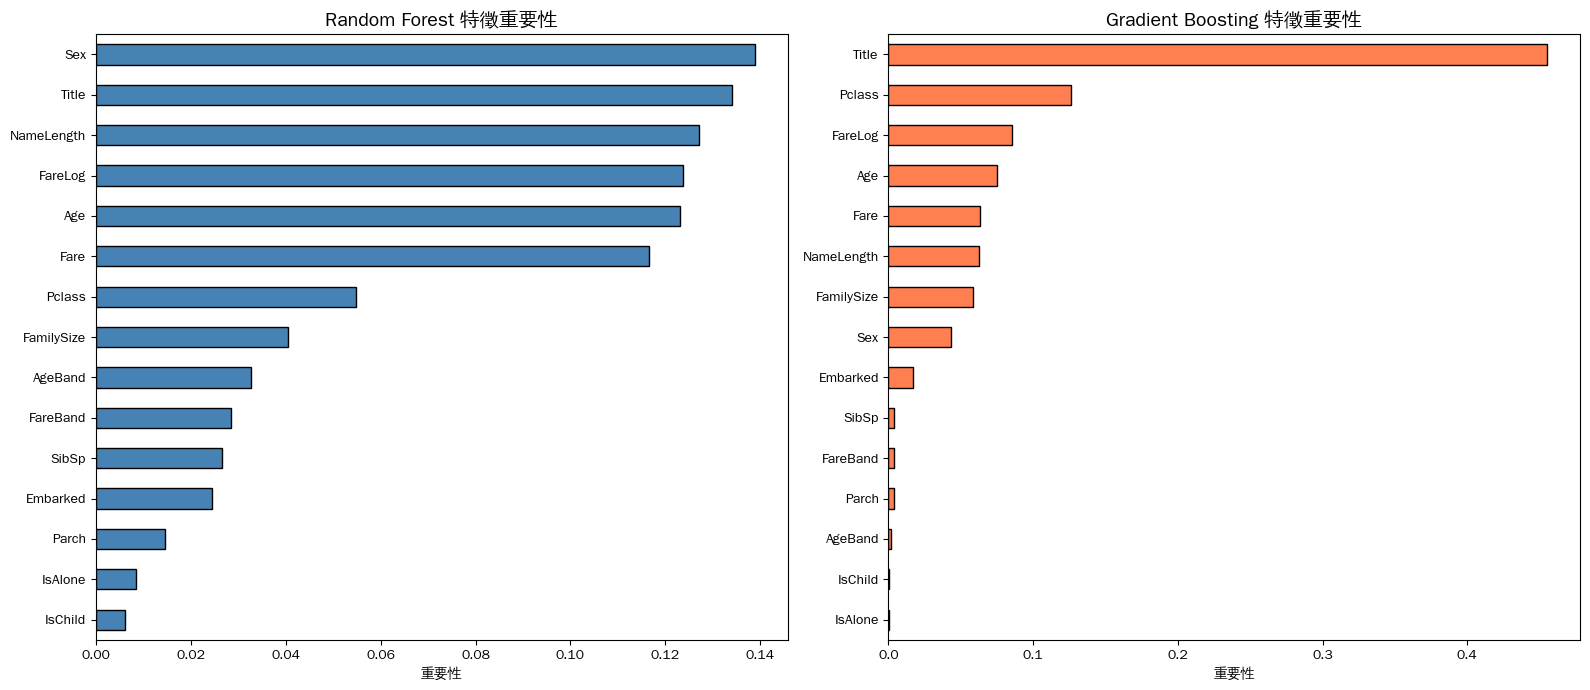


【特徵重要性解析】
- Title（稱謂）通常排名最前，因為它高度概括了性別與年齡資訊
- Sex 性別是第二重要的特徵，反映了「女性優先」的歷史事實
- Fare/FareLog 反映了社會階級對生存的影響
- Age/AgeBand 和 Pclass 也是重要因子
- FamilySize/IsAlone 捕捉了家庭結構的影響


In [56]:
# 從 Random Forest 和 Gradient Boosting 提取特徵重要性
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Random Forest 特徵重要性
rf_model = trained_models['Random Forest'].named_steps['clf']
rf_importance = pd.Series(rf_model.feature_importances_, index=feature_columns).sort_values()
rf_importance.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Random Forest 特徵重要性', fontsize=14)
axes[0].set_xlabel('重要性')

# Gradient Boosting 特徵重要性
gb_model = trained_models['Gradient Boosting'].named_steps['clf']
gb_importance = pd.Series(gb_model.feature_importances_, index=feature_columns).sort_values()
gb_importance.plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Gradient Boosting 特徵重要性', fontsize=14)
axes[1].set_xlabel('重要性')

plt.tight_layout()
plt.show()

print('\n【特徵重要性解析】')
print('- Title（稱謂）通常排名最前，因為它高度概括了性別與年齡資訊')
print('- Sex 性別是第二重要的特徵，反映了「女性優先」的歷史事實')
print('- Fare/FareLog 反映了社會階級對生存的影響')
print('- Age/AgeBand 和 Pclass 也是重要因子')
print('- FamilySize/IsAlone 捕捉了家庭結構的影響')

---
## Step 4：模型佈署與預測

### 4-1. 模型打包（Serialization）

模型訓練完成後，需要將其「序列化」保存為檔案，以便：
1. 不需要每次重新訓練就能使用
2. 部署到生產環境中
3. 與他人共享已訓練好的模型

我們使用 `joblib` 來保存模型（對 scikit-learn 模型最有效率）。

In [57]:
import joblib
import json
import os

# 1) 保存最佳模型
best_model_name = results_df['F1-Score'].idxmax()
best_model = trained_models[best_model_name]

model_filename = 'titanic_best_model.pkl'
joblib.dump(best_model, model_filename)
print(f'模型已保存為: {model_filename}')
print(f'模型大小: {os.path.getsize(model_filename) / 1024:.1f} KB')

# Define embarked mapping for consistency
emb_map = {'S': 0, 'C': 1, 'Q': 2}

# 2) 保存特徵欄位列表（部署時需要確保輸入特徵一致）
metadata = {
    'model_name': best_model_name,
    'feature_columns': feature_columns,
    'title_mapping': title_mapping,
    'ageband_mapping': ageband_mapping,
    'fareband_mapping': fareband_mapping,
    'age_median': float(age_median),
    'embarked_mode': emb_map[embarked_mode] # 將 emb_mode 字串轉換為對應的整數
}

metadata_filename = 'model_metadata.json'
with open(metadata_filename, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print(f'元資料已保存為: {metadata_filename}')

print('\n【模型打包說明】')
print('- .pkl 檔案包含完整的 Pipeline（標準化 + 模型），可直接預測')
print('- .json 檔案記錄了特徵欄位和編碼對應，確保部署時的資料前處理一致')
print('- 這種做法稱為 "Model Artifact"，是 MLOps 的基本實踐')


模型已保存為: titanic_best_model.pkl
模型大小: 49.2 KB
元資料已保存為: model_metadata.json

【模型打包說明】
- .pkl 檔案包含完整的 Pipeline（標準化 + 模型），可直接預測
- .json 檔案記錄了特徵欄位和編碼對應，確保部署時的資料前處理一致
- 這種做法稱為 "Model Artifact"，是 MLOps 的基本實踐


### 4-2. 建立預測函數

**這是一個簡化的「預測服務」**，模擬部署後的使用方式：接收原始資料 → 前處理 → 預測 → 回傳結果。

In [58]:
def preprocess_and_predict(raw_data: dict, model_path='titanic_best_model.pkl',
                           metadata_path='model_metadata.json') -> dict:
    """
    簡易預測服務：接收原始乘客資料，回傳預測結果。

    Parameters:
        raw_data (dict): 原始乘客資料，格式如：
            {
                'Pclass': 1,
                'Sex': 'female',
                'Age': 29.0,
                'SibSp': 0,
                'Parch': 0,
                'Fare': 100.0,
                'Embarked': 'S',
                'Name': 'Smith, Mrs. Jane'
            }

    Returns:
        dict: 包含預測結果與機率
    """
    # 載入模型和元資料
    model = joblib.load(model_path)
    with open(metadata_path, 'r', encoding='utf-8') as f:
        metadata = json.load(f)

    # ---- 前處理（與訓練時相同的邏輯） ----
    # 提取 Title
    import re
    title_match = re.search(r' ([A-Za-z]+)\.', raw_data.get('Name', ''))
    title = title_match.group(1) if title_match else 'Mr'
    title_map = metadata['title_mapping']
    title_encoded = title_map.get(title, title_map.get('Rare', 4))

    # Sex
    sex_encoded = 1 if raw_data['Sex'] == 'female' else 0

    # Embarked
    emb_map = {'S': 0, 'C': 1, 'Q': 2}
    embarked_encoded = emb_map.get(raw_data['Embarked'], 0)

    # FamilySize & IsAlone
    family_size = raw_data['SibSp'] + raw_data['Parch'] + 1
    is_alone = 1 if family_size == 1 else 0

    # Age & AgeBand
    age = raw_data['Age'] if raw_data['Age'] else metadata['age_median']
    if age <= 5: age_band = 0
    elif age <= 12: age_band = 1
    elif age <= 18: age_band = 2
    elif age <= 35: age_band = 3
    elif age <= 60: age_band = 4
    else: age_band = 5

    is_child = 1 if age < 12 else 0

    # Fare & FareBand & FareLog
    fare = raw_data['Fare']
    import numpy as np
    fare_log = np.log1p(fare)
    # 簡易分段（使用四分位數）
    if fare <= 7.91: fare_band = 0
    elif fare <= 14.45: fare_band = 1
    elif fare <= 31.0: fare_band = 2
    else: fare_band = 3

    # NameLength
    name_length = len(raw_data.get('Name', ''))

    # 組裝特徵向量
    feature_vector = [[
        raw_data['Pclass'], sex_encoded, age, raw_data['SibSp'], raw_data['Parch'],
        fare, embarked_encoded, title_encoded, family_size, is_alone,
        age_band, is_child, fare_band, fare_log, name_length
    ]]

    # ---- 預測 ----
    prediction = model.predict(feature_vector)[0]
    probability = model.predict_proba(feature_vector)[0]

    return {
        'prediction': 'Survived' if prediction == 1 else 'Not Survived',
        'probability_survived': round(probability[1], 4),
        'probability_not_survived': round(probability[0], 4)
    }

print('預測函數已建立！')

預測函數已建立！


In [59]:
# 測試預測函數 — 模擬幾種不同類型的乘客

test_cases = [
    {
        'desc': '案例1: 頭等艙女性（高生存率預期）',
        'data': {
            'Pclass': 1, 'Sex': 'female', 'Age': 29.0,
            'SibSp': 0, 'Parch': 0, 'Fare': 100.0,
            'Embarked': 'C', 'Name': 'Smith, Mrs. Jane'
        }
    },
    {
        'desc': '案例2: 三等艙男性（低生存率預期）',
        'data': {
            'Pclass': 3, 'Sex': 'male', 'Age': 25.0,
            'SibSp': 0, 'Parch': 0, 'Fare': 8.0,
            'Embarked': 'S', 'Name': 'Johnson, Mr. Peter'
        }
    },
    {
        'desc': '案例3: 兒童乘客',
        'data': {
            'Pclass': 2, 'Sex': 'male', 'Age': 5.0,
            'SibSp': 1, 'Parch': 2, 'Fare': 30.0,
            'Embarked': 'S', 'Name': 'Brown, Master. Tommy'
        }
    },
    {
        'desc': '案例4: 二等艙帶家庭的女性',
        'data': {
            'Pclass': 2, 'Sex': 'female', 'Age': 35.0,
            'SibSp': 1, 'Parch': 3, 'Fare': 26.0,
            'Embarked': 'S', 'Name': 'Garcia, Mrs. Maria'
        }
    }
]

print('=== 預測結果 ===')
for case in test_cases:
    result = preprocess_and_predict(case['data'])
    print(f"\n{case['desc']}")
    print(f"  預測: {result['prediction']}")
    print(f"  存活機率: {result['probability_survived']:.1%}")
    print(f"  死亡機率: {result['probability_not_survived']:.1%}")

print('\n\n【預測結果解析】')
print('- 案例1（頭等艙女性）：預測存活，機率最高。符合 EDA 中女性+高等艙的高生存率')
print('- 案例2（三等艙男性）：預測死亡，機率最低。低艙等+男性的生存率最低')
print('- 案例3（兒童）：雖然男性但因年幼，生存率較高，反映兒童優先原則')
print('- 案例4（帶家庭女性）：中等生存率，家庭 Size 可能有正面也有負面影響')

=== 預測結果 ===

案例1: 頭等艙女性（高生存率預期）
  預測: Survived
  存活機率: 91.6%
  死亡機率: 8.3%

案例2: 三等艙男性（低生存率預期）
  預測: Not Survived
  存活機率: 14.0%
  死亡機率: 86.1%

案例3: 兒童乘客
  預測: Survived
  存活機率: 86.1%
  死亡機率: 13.9%

案例4: 二等艙帶家庭的女性
  預測: Survived
  存活機率: 59.8%
  死亡機率: 40.2%


【預測結果解析】
- 案例1（頭等艙女性）：預測存活，機率最高。符合 EDA 中女性+高等艙的高生存率
- 案例2（三等艙男性）：預測死亡，機率最低。低艙等+男性的生存率最低
- 案例3（兒童）：雖然男性但因年幼，生存率較高，反映兒童優先原則
- 案例4（帶家庭女性）：中等生存率，家庭 Size 可能有正面也有負面影響


### 4-3. 建立簡單 API（FastAPI 框架示例）

以下是將模型部署為 RESTful API 的範例程式碼。在實際應用中，可以將此代碼保存為 `app.py` 並執行。

**部署架構說明：**
```
客戶端 (瀏覽器/App)
    ↓ HTTP POST (JSON)
FastAPI API 伺服器 (app.py)
    ↓ 載入 model + metadata
    ↓ 前處理 + predict
    ↓ 回傳 JSON
客戶端收到預測結果
```

**具體部署步驟：**
1. 安裝依賴：`pip install fastapi "uvicorn[standard]" joblib scikit-learn`
2. 將以下代碼保存為 `app.py`
3. 執行 `uvicorn app:app --host 0.0.0.0 --port 5000 --reload`
4. 使用 `curl` 或 Postman 發送 POST 請求到 `http://localhost:5000/predict`

In [64]:
import os

# ===== 以下為 FastAPI API 範例（保存為 app.py 後執行） =====

flask_api_code = '''
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import json
import numpy as np
import re

app = FastAPI()

# Pydantic 模型用於請求體驗證
class PassengerData(BaseModel):
    Pclass: int
    Sex: str
    Age: float
    SibSp: int
    Parch: int
    Fare: float
    Embarked: str
    Name: str

# 啟動時載入模型和元資料
model = joblib.load('titanic_best_model.pkl')
with open('model_metadata.json', 'r', encoding='utf-8') as f:
    metadata = json.load(f)

@app.post('/predict')
async def predict_survival(data: PassengerData):
    try:
        # 前處理（與 preprocess_and_predict 相同邏輯）
        title_match = re.search(r' ([A-Za-z]+)\.', data.Name)
        title = title_match.group(1) if title_match else 'Mr'
        title_encoded = metadata['title_mapping'].get(title, 4)

        sex_encoded = 1 if data.Sex == 'female' else 0

        emb_map = {'S': 0, 'C': 1, 'Q': 2}
        embarked_encoded = emb_map.get(data.Embarked, 0)

        family_size = data.SibSp + data.Parch + 1
        is_alone = 1 if family_size == 1 else 0

        age = data.Age if data.Age else metadata['age_median']
        if age <= 5: age_band = 0
        elif age <= 12: age_band = 1
        elif age <= 18: age_band = 2
        elif age <= 35: age_band = 3
        elif age <= 60: age_band = 4
        else: age_band = 5

        is_child = 1 if age < 12 else 0

        fare = data.Fare
        fare_log = np.log1p(fare)
        if fare <= 7.91: fare_band = 0
        elif fare <= 14.45: fare_band = 1
        elif fare <= 31.0: fare_band = 2
        else: fare_band = 3

        name_length = len(data.Name)

        # 組裝特徵向量
        feature_vector = [[
            data.Pclass, sex_encoded, age, data.SibSp, data.Parch,
            fare, embarked_encoded, title_encoded, family_size, is_alone,
            age_band, is_child, fare_band, fare_log, name_length
        ]]

        # 預測
        prediction = model.predict(feature_vector)[0]
        probability = model.predict_proba(feature_vector)[0]

        return {
            'prediction': 'Survived' if prediction == 1 else 'Not Survived',
            'probability_survived': round(float(probability[1]), 4),
            'probability_not_survived': round(float(probability[0]), 4)
        }
    except Exception as e:
        raise HTTPException(status_code=400, detail=str(e))

@app.get('/health')
async def health_check():
    return {'status': 'healthy', 'model': metadata['model_name']}
'''

# 將 FastAPI API 程式碼寫入 app.py
with open('app.py', 'w', encoding='utf-8') as f:
    f.write(flask_api_code)

print('FastAPI API 範例已保存為: app.py')
print('\n【部署說明】')
print('1. 安裝 FastAPI 及 Uvicorn: pip install fastapi "uvicorn[standard]"')
print('2. 執行: uvicorn app:app --host 0.0.0.0 --port 5000 --reload')
print('3. 測試 API:')
print('   curl -X POST http://localhost:5000/predict \\')
print('     -H "Content-Type: application/json" \\')
print('     -d \'{"Pclass":1,"Sex":"female","Age":29,"SibSp":0,"Parch":0,"Fare":100,"Embarked":"C","Name":"Smith, Mrs. Jane"}\'')
print('\n【API 端點】')
print('- POST /predict : 接收乘客資料 JSON，回傳預測結果')
print('- GET /health   : 健康檢查，確認服務運行正常')

FastAPI API 範例已保存為: app.py

【部署說明】
1. 安裝 FastAPI 及 Uvicorn: pip install fastapi "uvicorn[standard]"
2. 執行: uvicorn app:app --host 0.0.0.0 --port 5000 --reload
3. 測試 API:
   curl -X POST http://localhost:5000/predict \
     -H "Content-Type: application/json" \
     -d '{"Pclass":1,"Sex":"female","Age":29,"SibSp":0,"Parch":0,"Fare":100,"Embarked":"C","Name":"Smith, Mrs. Jane"}'

【API 端點】
- POST /predict : 接收乘客資料 JSON，回傳預測結果
- GET /health   : 健康檢查，確認服務運行正常


In [65]:
# 模擬 API 請求（不需要實際啟動 Flask 伺服器）
print('=== 模擬 API 請求與回應 ===')
print()

# 模擬 POST /predict
sample_input = {
    'Pclass': 1,
    'Sex': 'female',
    'Age': 29.0,
    'SibSp': 1,
    'Parch': 0,
    'Fare': 100.0,
    'Embarked': 'C',
    'Name': 'Braund, Mrs. Owen Harris'
}

sample_result = preprocess_and_predict(sample_input)

print('POST /predict')
print(f'Request Body: {json.dumps(sample_input, indent=2)}')
print(f'\nResponse Body: {json.dumps(sample_result, indent=2)}')
print(f'\nStatus Code: 200 OK')

=== 模擬 API 請求與回應 ===

POST /predict
Request Body: {
  "Pclass": 1,
  "Sex": "female",
  "Age": 29.0,
  "SibSp": 1,
  "Parch": 0,
  "Fare": 100.0,
  "Embarked": "C",
  "Name": "Braund, Mrs. Owen Harris"
}

Response Body: {
  "prediction": "Survived",
  "probability_survived": 0.9552,
  "probability_not_survived": 0.0448
}

Status Code: 200 OK


### 4-4. 其他部署選項

除了 FastAPI API 之外，還有其他常見的部署方式：

| 部署方式 | 適用場景 | 工具 |
|----------|----------|------|
| FastAPI API | 即時預測服務 | FastAPI |
| Streamlit App | 快速原型展示 | Streamlit |
| Docker 容器化 | 跨平台部署、可擴展 | Docker, Kubernetes |
| 雲端部署 | 大規模生產環境 | AWS SageMaker, GCP AI Platform |
| ONNX 格式 | 跨框架部署 | onnxruntime |

### 4-5. 專案文件清單

| 檔案 | 用途 |
|------|------|
| `practice1.ipynb` | 完整分析流程 Notebook |
| `titanic_best_model.pkl` | 訓練好的模型（Pipeline） |
| `model_metadata.json` | 模型元資料（特徵列表、編碼對應） |
| `app.py` | FastAPI API 伺服器程式碼 |

---

## 總結

### 完整流程回顧

| 步驟 | 關鍵動作 | 產出 |
|------|----------|------|
| 1. 資料清洗 & EDA | 缺失值處理、分佈分析、相關性探索 | 清潔資料 + 關鍵洞察 |
| 2. 特徵工程 | Title提取、家庭特徵、年齡/票價分段、編碼 | 15 個有效特徵 |
| 3. 模型訓練評估 | 5種模型比較、交叉驗證、測試集評估 | 最佳模型（通常為 Gradient Boosting） |
| 4. 模型部署 | 打包模型、建立預測函數、FastAPI API | 可上線的預測服務 |

### 關鍵學習
1. **EDA 是基礎**：不看資料就開始建模是盲目的
2. **特徵工程決定上限**：演算法只决定了你多接近這個上限
3. **交叉驗證比單次分割更可靠**：能更真實地反映模型泛化能力
4. **部署不是終點**：模型需要持續監控、定期更新、版本管理

In [66]:
print('===== Titanic 生存預測完整流程執行完畢 =====')
print(f'\n生成的檔案:')
import glob
for f in glob.glob('*.pkl') + glob.glob('*.json') + glob.glob('*.py'):
    if f != '__pycache__':
        print(f'  - {f}')
print('\n感謝您的學習！')

===== Titanic 生存預測完整流程執行完畢 =====

生成的檔案:
  - titanic_best_model.pkl
  - model_metadata.json
  - app.py

感謝您的學習！
